# 03 — Evaluación

Objetivo:
- Calcular el IoU de la segmentación contra el trimap real (mapeo oracle).
- Comparar K-Means contra baselines (Otsu, todo-foreground, aleatorio).
- Confirmar con números lo que vimos visualmente (¿HSV supera a RGB?).

Recordatorio: el IoU es cota superior (oracle-mapping), porque para asignar
qué cluster es foreground se usa la máscara real.

### 1. Preparar el entorno

In [9]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from src import config
from src import preprocessing as pp
from src import kmeans_segmentation as seg
from src import evaluation as ev
from src import visualization as viz

pairs = pp.list_pairs(config.IMAGES_DIR, config.TRIMAPS_DIR)
print("Pares cargados:", len(pairs))

Pares cargados: 7390


### 2. Primer IoU: una imagen, K=2

Segmentamos con K-Means (K=2), mapeamos los clusters a foreground/background
usando la máscara real (oracle), y calculamos el IoU contra el trimap,
ignorando el borde. Comparamos RGB vs HSV para confirmar lo que vimos visualmente.

In [10]:
# Imagen de ejemplo (la misma del notebook 02)
img_path, mask_path = pairs[0]
rgb = pp.load_image(img_path, resize_to=config.RESIZE_TO)
trimap = pp.load_mask(mask_path, resize_to=config.RESIZE_TO)

# Referencia binaria + máscara de píxeles válidos (borde ignorado)
gt_fg, valid = ev.trimap_to_binary(
    trimap,
    fg=config.TRIMAP_FOREGROUND,
    bg=config.TRIMAP_BACKGROUND,
    boundary=config.TRIMAP_BOUNDARY,
    ignore_boundary=config.IGNORE_BOUNDARY_IN_IOU,
)

# Calcular IoU para cada espacio de color con K=2
for espacio in ["rgb", "hsv", "hsv_circular"]:
    feats = pp.build_features(rgb, space=espacio)
    labels, _ = seg.segment_image(
        feats, config.RESIZE_TO, k=config.K_PRIMARY,
        random_state=config.RANDOM_STATE, n_init=config.N_INIT
    )
    pred_fg = ev.map_clusters_to_foreground(labels, gt_fg, valid)
    iou = ev.iou_foreground(pred_fg, gt_fg, valid)
    print(f"{espacio:15s} IoU = {iou:.3f}")

rgb             IoU = 0.000
hsv             IoU = 0.974
hsv_circular    IoU = 0.000


##### HSV = 0.974. Casi perfecto. Un IoU de 0.97 significa que la segmentación HSV coincide casi al 100% con el animal real. Justo lo que viste con los ojos: HSV separó al gato de forma impecable. Esto está muy por encima del baseline de 0.29, así que HSV aporta muchísimo aquí.

##### Con rgb casi nada queda marcado como foreground, y el IoU se va a cero. O sea, el 0.000 refleja fielmente que RGB fracasó totalmente en separar al animal en esta imagen. 

### 3. Comparar contra baselines

Un IoU alto solo significa algo comparado con métodos triviales. Medimos:
Otsu (umbral clásico), todo-foreground y aleatorio, sobre la misma imagen.

In [11]:
# Baselines sobre la misma imagen
otsu_labels = ev.otsu_as_two_cluster_labels(rgb)
otsu_fg = ev.map_clusters_to_foreground(otsu_labels, gt_fg, valid)
iou_otsu = ev.iou_foreground(otsu_fg, gt_fg, valid)

allfg = ev.baseline_all_foreground(config.RESIZE_TO)
iou_allfg = ev.iou_foreground(allfg, gt_fg, valid)

rnd = ev.baseline_random(config.RESIZE_TO, random_state=config.RANDOM_STATE)
iou_rnd = ev.iou_foreground(rnd, gt_fg, valid)

print(f"Otsu             IoU = {iou_otsu:.3f}")
print(f"Todo-foreground  IoU = {iou_allfg:.3f}")
print(f"Aleatorio        IoU = {iou_rnd:.3f}")
print()
print("(recordatorio) K-Means HSV IoU = 0.974")

Otsu             IoU = 0.000
Todo-foreground  IoU = 0.104
Aleatorio        IoU = 0.098

(recordatorio) K-Means HSV IoU = 0.974


### 4. Evaluación a escala: RGB vs HSV sobre muchas imágenes

Hasta ahora vimos una imagen. Para saber si "HSV gana" es un patrón real o
suerte, corremos K-Means (K=2) sobre una muestra grande y comparamos la
distribución de IoU de cada espacio de color. Reportamos media, mediana e IQR,
no solo el promedio, porque el IoU por imagen es muy variable.

In [12]:
# Evaluar RGB vs HSV vs HSV circular sobre una muestra
muestra = pairs[:200]   # sube este número si quieres más (más lento)
espacios = ["rgb", "hsv", "hsv_circular"]

iou_por_espacio = {esp: [] for esp in espacios}

for img_path, mask_path in muestra:
    rgb = pp.load_image(img_path, resize_to=config.RESIZE_TO)
    trimap = pp.load_mask(mask_path, resize_to=config.RESIZE_TO)
    gt_fg, valid = ev.trimap_to_binary(
        trimap,
        fg=config.TRIMAP_FOREGROUND,
        bg=config.TRIMAP_BACKGROUND,
        boundary=config.TRIMAP_BOUNDARY,
        ignore_boundary=config.IGNORE_BOUNDARY_IN_IOU,
    )
    for esp in espacios:
        feats = pp.build_features(rgb, space=esp)
        labels, _ = seg.segment_image(
            feats, config.RESIZE_TO, k=config.K_PRIMARY,
            random_state=config.RANDOM_STATE, n_init=config.N_INIT
        )
        pred_fg = ev.map_clusters_to_foreground(labels, gt_fg, valid)
        iou = ev.iou_foreground(pred_fg, gt_fg, valid)
        iou_por_espacio[esp].append(iou)

print(f"Evaluadas {len(muestra)} imágenes con K={config.K_PRIMARY}\n")
for esp in espacios:
    resumen = ev.summarize(iou_por_espacio[esp])
    print(f"{esp:15s} media={resumen['mean']:.3f}  mediana={resumen['median']:.3f}  IQR={resumen['iqr']:.3f}")

Evaluadas 200 imágenes con K=2

rgb             media=0.359  mediana=0.407  IQR=0.634
hsv             media=0.421  mediana=0.511  IQR=0.751
hsv_circular    media=0.460  mediana=0.571  IQR=0.802


### 5. Distribución del IoU por espacio de color

Un boxplot muestra no solo el promedio sino la variabilidad. Esperamos ver
cajas altas (buen IoU) pero muy estiradas (rendimiento variable entre imágenes).

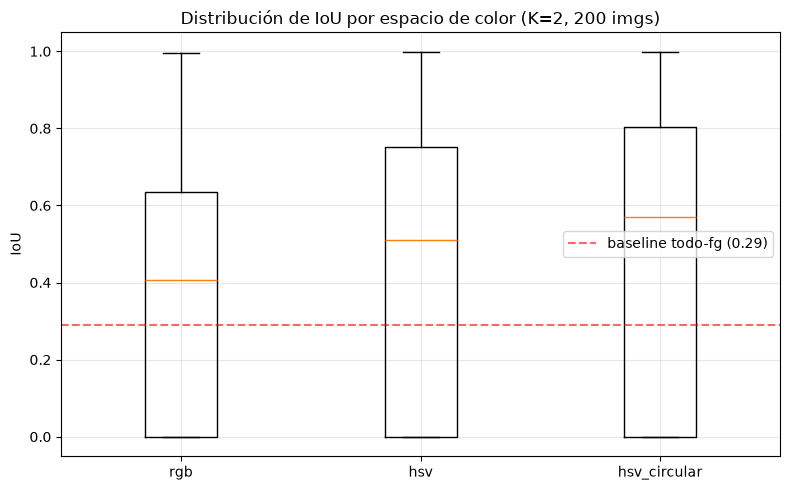

In [14]:
# Boxplot de la distribución de IoU por espacio de color
datos = [
    [v for v in iou_por_espacio[esp] if not np.isnan(v)]
    for esp in espacios
]

fig, ax = plt.subplots(figsize=(8, 5))
ax.boxplot(datos, tick_labels=espacios)
ax.axhline(0.29, color="red", linestyle="--", alpha=0.6, label="baseline todo-fg (0.29)")
ax.set_ylabel("IoU")
ax.set_title(f"Distribución de IoU por espacio de color (K={config.K_PRIMARY}, {len(muestra)} imgs)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
config.FIGURES.mkdir(parents=True, exist_ok=True)
fig.savefig(config.FIGURES / "iou_por_espacio_color.png", dpi=120, bbox_inches="tight")
print("Figura guardada en:", config.FIGURES / "iou_por_espacio_color.png")

Figura guardada en: C:\Proyectos de VS\image-segmentation-kmeans\results\figures\iou_por_espacio_color.png
